# Hipótese: Antecedência do cancelamento x Taxa de detratores

Testa se o tempo de antecedência do aviso de cancelamento de voo (`ANTECEDENCIA_CANCELAMENTO`)
está associado à taxa de passageiros detratores (`NPS_PRINCIPAL == -100`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 150)

## 1. Carregar e unir as bases

In [2]:
nps = pd.concat(
    [pd.read_csv(f'PROJETO_INTELI_NPS_0{i}.csv') for i in range(1, 5)],
    ignore_index=True
)

viagem = pd.read_csv('PROJETO_INTELI_INFORMACAO_VIAGEM.csv')

df = nps.merge(viagem, on='RESPONDENT_ID', how='inner')
df['DETRATOR'] = df['NPS_PRINCIPAL'] == -100

print(f'Total de respostas: {len(df)}')
df.head()

Total de respostas: 484916


,RESPONDENT_ID,ID_GOLDENRECORD,DATA_STD,EQUIPAMENTO_TIPO,BASE_AIRPORTLEG,VOO_TIPO,VOO_NUMERO,TIPO_ENTRETENIMENTO,NPS_PRINCIPAL,NPS_ATRASO,...,SUB_FIL_FREQUENCIAAZUL,VOO_INTERNACIONAL,TEMPO_VOO,CANAL_COMPRA,CANCELAMENTO_VOO,ANTECEDENCIA_CANCELAMENTO,ATRASO_CHEGADA,ESTATISTICA_ATRASOSAIDA,ASSENTOS,DETRATOR
0,28211922,19015895.0,2023-07-01,32N/AT9/295,FOR/UDI/CNF/POA,Conexão,2568/4922/4219,NaN,-100,NaN,...,De 2 a 5 vezes por ano,Domestic,640.0,Web,False,NaN,0,7,20A/17A/28A,True
1,28211924,64251508.0,2023-07-01,295,CWB/CNF,Direto,2743,GRAVADO,100,NaN,...,Esta foi a primeira vez,Domestic,90.0,Agency,False,NaN,0,0,26D,False
2,28211938,57482712.0,2023-07-01,32N,SDU/BSB,Direto,4800,AO VIVO,100,NaN,...,De 2 a 5 vezes por ano,Domestic,110.0,Web,False,NaN,0,9,1B,False
3,28211953,14506222.0,2023-07-01,295,IGU/POA,Direto,2978,GRAVADO,-100,NaN,...,De 2 a 5 vezes por ano,Domestic,75.0,Mobile,False,NaN,0,0,10B,True
4,28211984,168477005.0,2023-07-01,32N,NAT/VCP,Direto,2401,NÃO TEM ENTRETENIMENTO,100,NaN,...,Esta foi a primeira vez,Domestic,210.0,Agency,False,NaN,0,0,23E,False


## 2. Isolar voos cancelados e comparar com voos não cancelados

In [3]:
taxa_geral = df.groupby('CANCELAMENTO_VOO')['DETRATOR'].mean()
print(taxa_geral)

CANCELAMENTO_VOO
False    0.181997
True     0.434235
Name: DETRATOR, dtype: float64


## 3. Segmentar cancelamentos por faixa de antecedência

In [4]:
cancelados = df[df['CANCELAMENTO_VOO'] == True].copy()

bins = [-1, 0, 6, 24, 48, np.inf]
labels = ['0h (em cima)', '1-6h', '7-24h', '25-48h', '>48h']
cancelados['FAIXA_ANTECEDENCIA'] = pd.cut(
    cancelados['ANTECEDENCIA_CANCELAMENTO'], bins=bins, labels=labels
)

tabela = cancelados.groupby('FAIXA_ANTECEDENCIA')['DETRATOR'].agg(
    pct_detrator='mean', n='size'
)
tabela

,pct_detrator,n
FAIXA_ANTECEDENCIA,,
0h (em cima),0.691973,12197
1-6h,0.523474,6816
7-24h,0.342600,7122
25-48h,0.258837,8515
>48h,0.245565,8511


## 4. Visualizar o gradiente

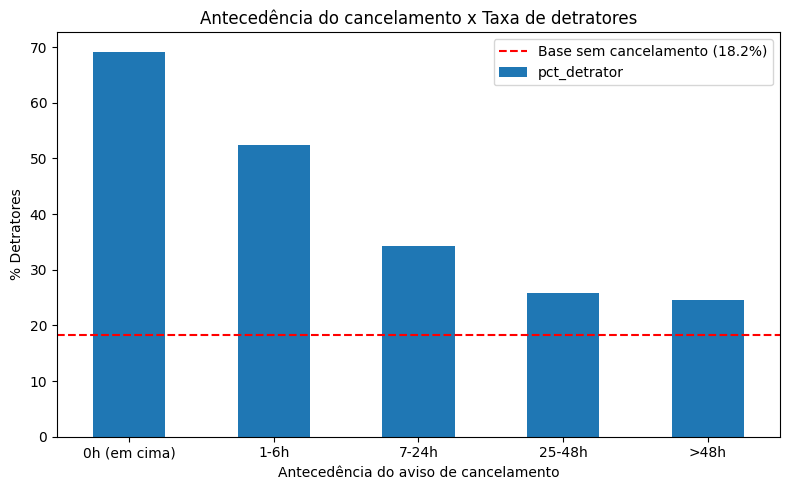

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
tabela['pct_detrator'].mul(100).plot(kind='bar', ax=ax, color='#1f77b4')

taxa_base = df[df['CANCELAMENTO_VOO'] == False]['DETRATOR'].mean() * 100
ax.axhline(taxa_base, color='red', linestyle='--',
           label=f'Base sem cancelamento ({taxa_base:.1f}%)')

ax.set_ylabel('% Detratores')
ax.set_xlabel('Antecedência do aviso de cancelamento')
ax.set_title('Antecedência do cancelamento x Taxa de detratores')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Teste estatístico de associação (qui-quadrado)

In [6]:
tabela_contingencia = pd.crosstab(cancelados['FAIXA_ANTECEDENCIA'], cancelados['DETRATOR'])
chi2, p, dof, expected = stats.chi2_contingency(tabela_contingencia)

print(f'chi2 = {chi2:.2f}')
print(f'p-valor = {p:.2e}')
print(f'graus de liberdade = {dof}')

chi2 = 6061.83
p-valor = 0.00e+00
graus de liberdade = 4


In [7]:
corr = cancelados['ANTECEDENCIA_CANCELAMENTO'].corr(cancelados['NPS_PRINCIPAL'])
print(f'Correlação ANTECEDENCIA_CANCELAMENTO x NPS_PRINCIPAL: {corr:.3f}')

Correlação ANTECEDENCIA_CANCELAMENTO x NPS_PRINCIPAL: 0.280


In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

modelo_df = cancelados.dropna(subset=['ANTECEDENCIA_CANCELAMENTO', 'DETRATOR']).copy()
modelo_df['DETRATOR'] = modelo_df['DETRATOR'].astype(int)

modelo = smf.logit(
    'DETRATOR ~ ANTECEDENCIA_CANCELAMENTO',
    data=modelo_df
).fit()

print(modelo.summary())
print()
print('Odds ratio por hora de antecedência:', np.exp(modelo.params['ANTECEDENCIA_CANCELAMENTO']))

Optimization terminated successfully.
         Current function value: 0.640416
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               DETRATOR   No. Observations:                43161
Model:                          Logit   Df Residuals:                    43159
Method:                           MLE   Df Model:                            1
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                 0.06437
Time:                        17:20:21   Log-Likelihood:                -27641.
converged:                       True   LL-Null:                       -29542.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.2456      0.013     18.910      0.000       0.

## Conclusão

- A taxa de detratores cai de forma gradual conforme aumenta a antecedência do aviso de cancelamento (69,2% → 24,6%), aproximando-se da taxa base de voos sem cancelamento (18,2%).
- O teste qui-quadrado confirma associação estatisticamente significativa entre a faixa de antecedência e a taxa de detratores.